# Lab IV: Linear Models
### Answer all three sets of questions

**Q0.** Please answer the following questions in your own words.

1. What makes a model "linear"? "Linear" in what?
    A model is considered linear if the output is a linear combination of the inputs and the coefficients. It is linear in the relationship

2. How do you interpret the coefficient for a dummy/one-hot-encoded variable? (This is a trick question, and the trick involves how you handle the intercept of the model.) There's further explanation at the end of this document, if needed.
    After making one of the dummy variables your reference category, the coefficients for dummy variables represent the expected difference between that variable and the reference category. 

3. Can linear regression be used for classification? Explain why, or why not.
    Technically, yes, because you could set thresholds or "bins" on your dependent variable to create categories. That said, there are better options for classifications.

4. If you have a high accuracy on training but low on testing, what might be the problem? It's also possible you'll see a pattern in the residuals. 
    Overfitting sounds like it's the problem here! Perhaps your train test split was not the right ratio.

5. Review this page: [Non-Linear with Linear](https://inria.github.io/scikit-learn-mooc/python_scripts/linear_regression_non_linear_link.html) What are two ways to incorporate nonlinear relationships between your target/response/dependent/outcome variable $y$ and your features/control/response/independent variables $x$?
    Polynomial regression and binned regression.

6. What is the interpretation of the intercept? A slope coefficient for a variable? The coefficient for a dummy/one-hot-encoded variable?
    The intercept is what you would expect Y variable to be given that the reference variable is true and all other variables are zero.
    The slope coefficient for a variable is the expected change in Y per unit of X
    The coefficient for a dummy variable is how much on average Y varies from one category to the reference category.

**Q1.** Load clean q1_clean: https://raw.githubusercontent.com/DS3001/linearRegression/refs/heads/main/data/Q1_clean.csv 

The data include

- `Price` per night
- `Review Scores Rating`: The average rating for the property
- `Neighborhood `: The bourough of NYC. Note the space, or rename the variable.
- `Property Type`: The kind of dwelling
- `Room Type`: The kind of space being rented

1. Compute the average prices and scores by `Neighborhood `; which borough is the most expensive on average? Create a kernel density plot of price and log price, grouping by `Neighborhood `.
2. Regress price on `Neighborhood ` by creating the appropriate dummy/one-hot-encoded variables, without an intercept in the linear model. Compare the coefficients in the regression to the table from part 1. What pattern do you see? What are the coefficients in a regression of a continuous variable on one categorical variable?
3. Repeat part 2, but leave an intercept in the linear model. How do you have to handle the creation of the dummies differently? What is the intercept? Interpret the coefficients. How can I get the coefficients in part 2 from these new coefficients?
4. Split the sample 80/20 into a training and a test set. Run a regression of `Price` on `Review Scores Rating` and `Neighborhood `. What is the $R^2$ and RMSE on the test set? What is the coefficient on `Review Scores Rating`? What is the most expensive kind of property you can rent?
5. Run a regression of `Price` on `Review Scores Rating` and `Neighborhood ` and `Property Type`. What is the $R^2$ and RMSE on the test set? What is the coefficient on `Review Scores Rating`? What is the most expensive kind of property you can rent?
6. What does the coefficient on `Review Scores Rating` mean if it changes from part 4 to 5? Hint: Think about how multiple linear regression works.
7. (Optional) We've included `Neighborhood ` and `Property Type` separately in the model. How do you interact them, so you can have "A bedroom in Queens" or "A townhouse in Manhattan". Split the sample 80/20 into a training and a test set and run a regression including that kind of "property type X neighborhood" dummy, plus `Review Scores Rating`. How does the slope coefficient for `Review Scores Rating`, the $R^2$, and the RMSE change? Do they increase significantly compares to part 5? Are the coefficients in this regression just the sum of the coefficients for `Neighbourhood ` and `Property Type` from 5? What is the most expensive kind of property you can rent?

In [19]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

In [2]:
houses = pd.read_csv("https://raw.githubusercontent.com/DS3001/linearRegression/refs/heads/main/data/Q1_clean.csv")
houses.head()

,Price,Review Scores Rating,Neighbourhood,Property Type,Room Type
0,549,96.0,Manhattan,Apartment,Private room
1,149,100.0,Brooklyn,Apartment,Entire home/apt
2,250,100.0,Manhattan,Apartment,Entire home/apt
3,90,94.0,Brooklyn,Apartment,Private room
4,270,90.0,Manhattan,Apartment,Entire home/apt


In [11]:
nhoods = houses.groupby('Neighbourhood ').agg({
    'Price': 'mean',
    'Review Scores Rating': 'mean'
})

print(nhoods)

                     Price  Review Scores Rating
Neighbourhood                                   
Bronx            75.276498             91.654378
Brooklyn        127.747378             92.363497
Manhattan       183.664286             91.801496
Queens           96.857233             91.549057
Staten Island   146.166667             90.843750


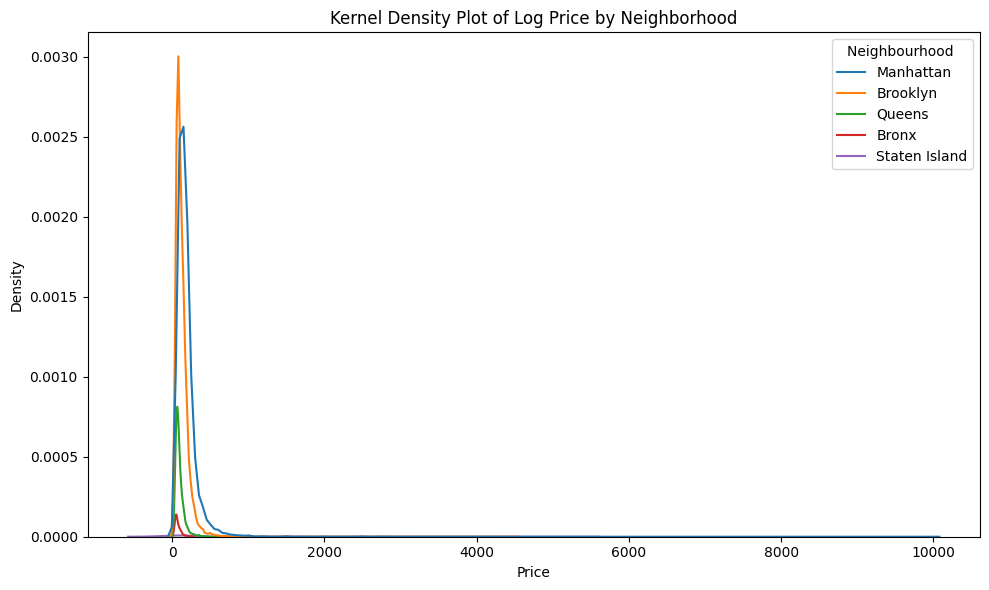

In [22]:
# Set up the matplotlib figure
plt.figure(figsize=(10, 6))

# Kernel density plot for log(price)
sns.kdeplot(data=houses, x='Price', hue='Neighbourhood ')
plt.title('Kernel Density Plot of Log Price by Neighborhood')

# Show the plot
plt.tight_layout()
plt.show()

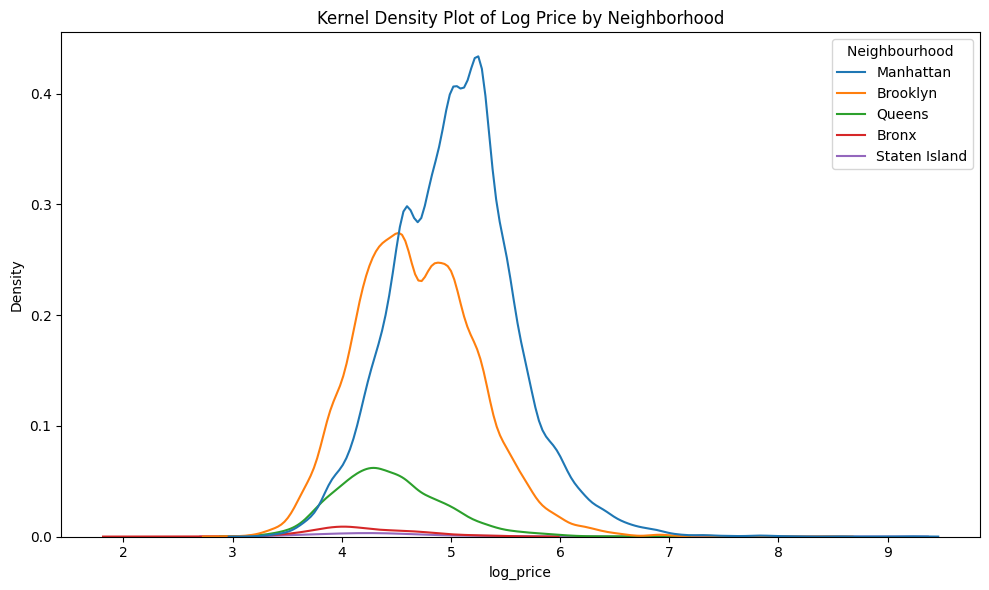

In [23]:
# Calculate log(price)
houses['log_price'] = np.log(houses['Price'])

# Set up the matplotlib figure
plt.figure(figsize=(10, 6))

# Kernel density plot for log(price)
sns.kdeplot(data=houses, x='log_price', hue='Neighbourhood ')
plt.title('Kernel Density Plot of Log Price by Neighborhood')

# Show the plot
plt.tight_layout()
plt.show()

Manhattan is the most expensive burrow on average.

**Q2.** This question is a case study for linear models. The data are about car prices. In particular, they include:

  - `Price`, `Color`, `Seating_Capacity`
  - `Body_Type`: crossover, hatchback, muv, sedan, suv
  - `Make`, `Make_Year`: The brand of car and year produced
  - `Mileage_Run`: The number of miles on the odometer
  - `Fuel_Type`: Diesel or gasoline/petrol
  - `Transmission`, `Transmission_Type`:  speeds and automatic/manual

  1. Load `cars_hw.csv`. These data were really dirty, and I've already cleaned them a significant amount in terms of missing values and other issues, but some issues remain (e.g. outliers, badly skewed variables that require a log or arcsinh transformation) Note this is different than normalizing: there is a text below that explains further. Clean the data however you think is most appropriate.
  2. Summarize the `Price` variable and create a kernel density plot. Use `.groupby()` and `.describe()` to summarize prices by brand (`Make`). Make a grouped kernel density plot by `Make`. Which car brands are the most expensive? What do prices look like in general?
  3. Split the data into an 80% training set and a 20% testing set.
  4. Make a model where you regress price on the numeric variables alone; what is the $R^2$ and `RMSE` on the training set and test set? Make a second model where, for the categorical variables, you regress price on a model comprised of one-hot encoded regressors/features alone (you can use `pd.get_dummies()`; be careful of the dummy variable trap); what is the $R^2$ and `RMSE` on the test set? Which model performs better on the test set? Make a third model that combines all the regressors from the previous two; what is the $R^2$ and `RMSE` on the test set? Does the joint model perform better or worse, and by home much?
  5. Use the `PolynomialFeatures` function from `sklearn` to expand the set of numerical variables you're using in the regression. As you increase the degree of the expansion, how do the $R^2$ and `RMSE` change? At what point does $R^2$ go negative on the test set? For your best model with expanded features, what is the $R^2$ and `RMSE`? How does it compare to your best model from part 4?
  6. For your best model so far, determine the predicted values for the test data and plot them against the true values. Do the predicted values and true values roughly line up along the diagonal, or not? Compute the residuals/errors for the test data and create a kernel density plot. Do the residuals look roughly bell-shaped around zero? Evaluate the strengths and weaknesses of your model.

**Q3.**
1. Find a dataset on a topic you're interested in. Some easy options are data.gov, kaggle.com, and data.world.
2. Clean the data and do some exploratory data analysis on key variables that interest you. Pick a particular target/outcome variable and features/predictors.
3. Split the sample into an ~80% training set and a ~20% test set.
4. Run a few regressions of your target/outcome variable on a variety of features/predictors. Compute the RMSE on the test set.
5. Which model performed the best, and why?
6. What did you learn?

:::{important}
### Dummy Variable Trap 


In linear regression with categorical variables you should be careful of the Dummy Variable Trap. 
The Dummy Variable trap is a scenario in which the independent variables are multicollinear - a 
scenario in which two or more variables are highly correlated; in simple terms one variable can 
be predicted from the others. This can produce singularity of a model, meaning your model just won't 
work. Read about it here

Idea is to use dummy variable encoding with drop_first=True, this will omit one column from each 
category after converting categorical variable into dummy/indicator variables. You WILL NOT lose 
and relevant information by doing that simply because your all point in dataset can fully be 
explained by rest of the features.

Here is complete code on how you can do it for a "jobs" dataset

So you have your X features:

Age, Gender, Job, Classification 

And one numerical features that you are trying to predict:

Wage

First you need to split your initial dataset on input variables and prediction, 
assuming its pandas dataframe it would look like this:

Input variables (your dataset is bit different but whole code remains the same, 
you will put every column from dataset in X, except one that will go to Y. pd.get_dummies 
works without problem like that - it will just convert categorical variables and it won't 
touch numerical):

X = jobs[['Age','Gender','Job','Classification']]

Prediction:

Y = jobs['Wage']

Convert categorical variable into dummy/indicator variables and drop one in each category:

X = pd.get_dummies(data=X, drop_first=True)

So now if you check shape of X (X.shape) with drop_first=True you will see that it has 
4 columns less - one for each of your categorical variables.

You can now continue to use them in your linear model. For scikit-learn implementation it 
could look like this:
:::

In [ ]:
from sklearn import linear_model
from sklearn.model_selection import train_test_split
    
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size = .20, random_state = 40)
    
regr = linear_model.LinearRegression() # Do not use fit_intercept = False if you have removed 
1 column after dummy encoding

regr.fit(X_train, Y_train)
predicted = regr.predict(X_test)

:::{tip}
### Transformation versus Normalization

Use a **log transformation** when your data is strictly positive and heavily skewed towards larger values (right-skewed), while an **arcsinh transformation** is better suited for data with both positive and negative values, or when you need to handle potential zero values; **normalize** your data when you need to scale all values to a similar range, typically between 0 and 1, and especially when using algorithms sensitive to feature scale, but not necessarily to achieve a **normal distribution**. 
Key points about each transformation: 

    Log transformation: 

    Best for positively skewed data with large variations in magnitude. 

Useful when analyzing relative changes rather than absolute differences. 
Cannot handle negative values. 

Arcsinh transformation:

    Can handle both positive and negative data. 

Effective for data with extreme values on both ends of the spectrum. 
Often used when dealing with proportions or percentages near 0 or 1. 

Normalization: 

    Scales data to a common range, usually between 0 and 1. 

Useful when comparing features with different scales in machine learning algorithms. 
Does not necessarily transform the data distribution to be normal. 

:::
